In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Loading and reading out the first 5 rows of dataset

In [3]:
df = pd.read_csv("cc_general_raw.csv")

In [3]:
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


## Phase 1.Data Cleaning

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

We have total of 18 columns and 8950 rows.Columns-> 17 numerical and 1 categorical.There are null values present for credit limit and minimum payment

In [5]:
df.describe(include='all')

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
unique,8950,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,C10001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,NaN,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,NaN,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,NaN,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,NaN,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000


#### Checking for null values

In [6]:
df.isna().sum()

CUST_ID                               0
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

In [7]:
df.isna().sum().sum()

np.int64(314)

There are 314 null value in the dataset

In [8]:
null_percent = df.isna().sum().sum()/len(df)*100
print(null_percent)

3.5083798882681565


Total of 3.5 % null values exists in the dataset

#### Checking for duplicate customer IDs

In [9]:
df.duplicated("CUST_ID").sum()

np.int64(0)

There are no duplicate customers in the dataset

#### Checking for cases where the minimum payment is null and payments is zero

In [10]:
df[(df['MINIMUM_PAYMENTS'].isnull()) & (df['PAYMENTS']== 0)]

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.0,NaN,0.0,12
45,C10047,2242.311686,1.000000,437.00,97.00,340.0,184.648692,0.333333,0.083333,0.333333,0.166667,2,5,2400.0,0.0,NaN,0.0,12
47,C10049,3910.111237,1.000000,0.00,0.00,0.0,1980.873201,0.000000,0.000000,0.000000,0.500000,7,0,4200.0,0.0,NaN,0.0,12
55,C10057,1311.995984,1.000000,1283.90,1283.90,0.0,0.000000,0.250000,0.250000,0.000000,0.000000,0,6,6000.0,0.0,NaN,0.0,12
56,C10058,3625.218146,1.000000,313.27,313.27,0.0,668.468743,0.250000,0.250000,0.000000,0.416667,5,4,4000.0,0.0,NaN,0.0,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8854,C19095,3.833185,0.125000,45.00,45.00,0.0,0.000000,0.125000,0.125000,0.000000,0.000000,0,1,500.0,0.0,NaN,0.0,8
8919,C19160,14.524779,0.333333,152.00,152.00,0.0,0.000000,0.333333,0.333333,0.000000,0.000000,0,2,1500.0,0.0,NaN,0.0,6
8929,C19170,371.527312,0.333333,0.00,0.00,0.0,1465.407927,0.000000,0.000000,0.000000,0.166667,5,0,1500.0,0.0,NaN,0.0,6
8935,C19176,183.817004,1.000000,465.90,0.00,465.9,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1500.0,0.0,NaN,0.0,6


There 240 rows where payments is 0 and minimum_payment is null

In [11]:
df["MINIMUM_PAYMENTS"] = np.where((df["MINIMUM_PAYMENTS"].isnull()) & (df["PAYMENTS"] == 0),0,df["MINIMUM_PAYMENTS"])

In [12]:
df.isna().sum().sum()

np.int64(74)

In [13]:
df.isna().sum().sum()/len(df)*100

np.float64(0.8268156424581006)

Total of 0.8 % null values exists in the dataset

In [14]:
df = df.dropna()

In [15]:
df.isna().sum()

CUST_ID                             0
BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64

#### Making all column name in snake casing

In [16]:
df.columns

Index(['CUST_ID', 'BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES',
       'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE',
       'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY',
       'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY',
       'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS',
       'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE'],
      dtype='object')

In [17]:
df.columns = df.columns.str.lower()

In [18]:
df.columns

Index(['cust_id', 'balance', 'balance_frequency', 'purchases',
       'oneoff_purchases', 'installments_purchases', 'cash_advance',
       'purchases_frequency', 'oneoff_purchases_frequency',
       'purchases_installments_frequency', 'cash_advance_frequency',
       'cash_advance_trx', 'purchases_trx', 'credit_limit', 'payments',
       'minimum_payments', 'prc_full_payment', 'tenure'],
      dtype='object')

### Data Cleaning Summary
- Total nulls before cleaning: 313 (MINIMUM_PAYMENTS) + 1 (CREDIT_LIMIT)
- 240 MINIMUM_PAYMENTS nulls filled with 0 where PAYMENTS = 0
  (no payment made, so minimum payment is logically 0)
- Remaining nulls dropped = 73(payment recorded but minimum payment unknown, no reliable assumption) and 1(credit limit s null)
- No duplicate CUST_ID found
- Column names converted to snake case for consistency
- Final dataset: 8,876 clean rows

## Phase 2: Exploratory Data Analysis (EDA)

### Analysis Questions with each theme

| S.no | Theme | Column | Business Question |
|---|-------|--------|------------------|
| 1 | Spending behaviour | `PURCHASES` | Are most customers low spenders or is spending concentrated in a small group? |
| 2 | Cash risk | `CASH_ADVANCE` | Is cash borrowing a minority behaviour or widespread? |
| 3 | Payment health | `PAYMENTS` | Are most customers making small payments or is repayment spread? |
| 4 | Credit exposure | `BALANCE` | Is portfolio debt carried by a few or spread evenly? |
| 5 | Engagement | `PURCHASES_FREQUENCY` | Are there two distinct types: active vs inactive? |

#### Q1 . Are most customers low spenders or is spending spread across the portfolio?

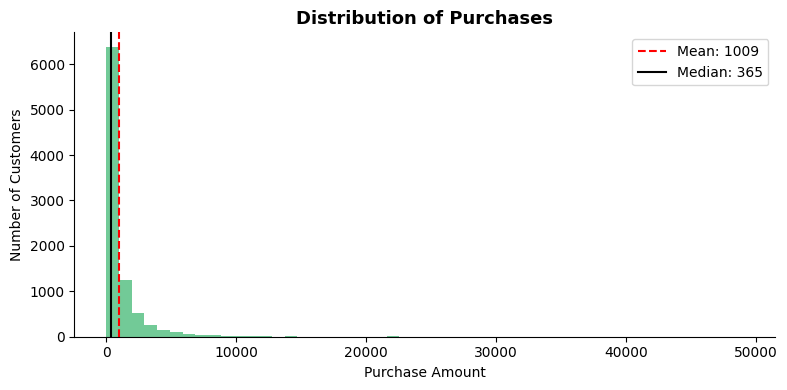

In [19]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df['purchases'], bins=50, color='#27AE60', alpha=0.65,edgecolor="none")
ax.axvline(df['purchases'].mean(), color='red', linestyle='--', linewidth=1.5,
           label=f"Mean: {df['purchases'].mean():.0f}")
ax.axvline(df['purchases'].median(), color='black', linestyle='-', linewidth=1.5,
           label=f"Median: {df['purchases'].median():.0f}")
ax.set_title('Distribution of Purchases', fontsize=13, fontweight='bold')
ax.set_xlabel('Purchase Amount')
ax.set_ylabel('Number of Customers')
ax.legend()
sns.despine(ax=ax)
plt.tight_layout()

In [20]:
print(f"Mean:                    {df['purchases'].mean():.2f}")
print(f"Median:                  {df['purchases'].median():.2f}")
print(f"Skewness:                {df['purchases'].skew():.2f}")
print(f"Zero purchases:          {(df['purchases']==0).sum()}  ({(df['purchases']==0).mean()*100:.1f}%)")

Mean:                    1008.89
Median:                  365.00
Skewness:                8.12
Zero purchases:          2035  (22.9%)


**Finding:** Distribution is heavily right-skewed (skew = 8.12). Mean (1,008) is almost 3x the median (365). 22.9% of customers have zero purchases  majority are low or inactive spenders. A small group drives all the spend.

#### Q2 . Is cash advance usage concentrated in a small group or spread across all customers?

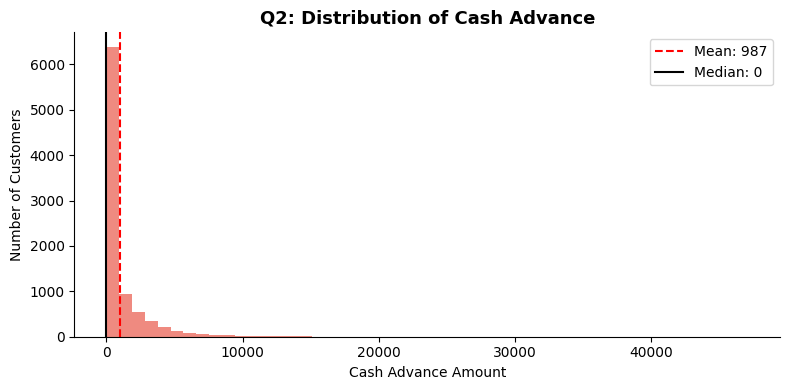

In [21]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(df['cash_advance'], bins=50, color='#E74C3C', alpha=0.65, edgecolor='none')
ax.axvline(df['cash_advance'].mean(),color='red',linestyle='--', linewidth=1.5,
           label=f"Mean: {df['cash_advance'].mean():.0f}")
ax.axvline(df['cash_advance'].median(), color='black', linestyle='-', linewidth=1.5,
           label=f"Median: {df['cash_advance'].median():.0f}")

ax.set_title('Q2: Distribution of Cash Advance', fontsize=13, fontweight='bold')
ax.set_xlabel('Cash Advance Amount')
ax.set_ylabel('Number of Customers')
ax.legend()
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

In [22]:
print(f"Mean:                    {df['cash_advance'].mean():.2f}")
print(f"Median:                  {df['cash_advance'].median():.2f}")
print(f"Skewness:                {df['cash_advance'].skew():.2f}")
print(f"Zero cash advance:       {(df['cash_advance']==0).sum()} ({(df['cash_advance']==0).mean()*100:.1f}%)")

Mean:                    986.74
Median:                  0.00
Skewness:                5.15
Zero cash advance:       4564 (51.4%)


**Finding:** Median = 0. More than half (51.4%) never use cash advances. However 48.6% do, with a long right tail showing some customers borrowing very heavily. This is a concentrated risk signal.

#### Q3 . Are customers paying back proportionally to what they owe or falling behind?

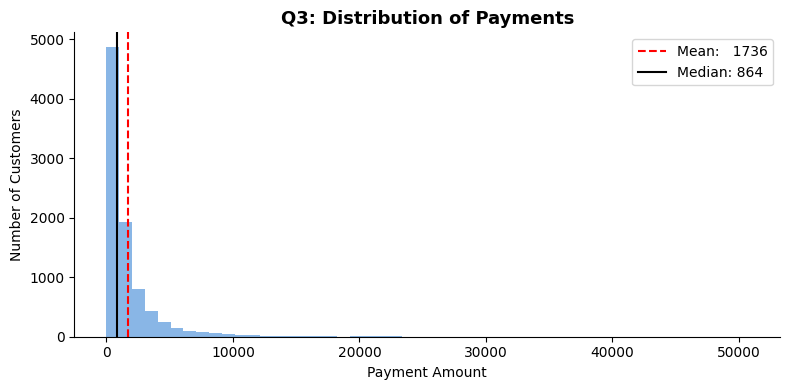

In [23]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(df['payments'], bins=50, color='#4A90D9', alpha=0.65, edgecolor='none')
ax.axvline(df['payments'].mean(), color='red', linestyle='--', linewidth=1.5,
           label=f"Mean:   {df['payments'].mean():.0f}")
ax.axvline(df['payments'].median(), color='black', linestyle='-', linewidth=1.5,
           label=f"Median: {df['payments'].median():.0f}")

ax.set_title('Q3: Distribution of Payments', fontsize=13, fontweight='bold')
ax.set_xlabel('Payment Amount')
ax.set_ylabel('Number of Customers')
ax.legend()
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

In [24]:
print(f"Mean:                    {df['payments'].mean():.2f}")
print(f"Median:                  {df['payments'].median():.2f}")
print(f"Skewness:                {df['payments'].skew():.2f}")
print(f"Zero payments:           {(df['payments']==0).sum()} ({(df['payments']==0).mean()*100:.1f}%)")

Mean:                    1736.23
Median:                  863.85
Skewness:                5.91
Zero payments:           240 (2.7%)


**Finding:** Right-skewed (skew = 5.91). Mean (1,736) is double the median (863). Most customers make small payments. A small group makes very large payments — likely high-spend customers clearing large balances.

#### Q4 . Is outstanding balance concentrated in a few high-risk customers or distributed evenly?

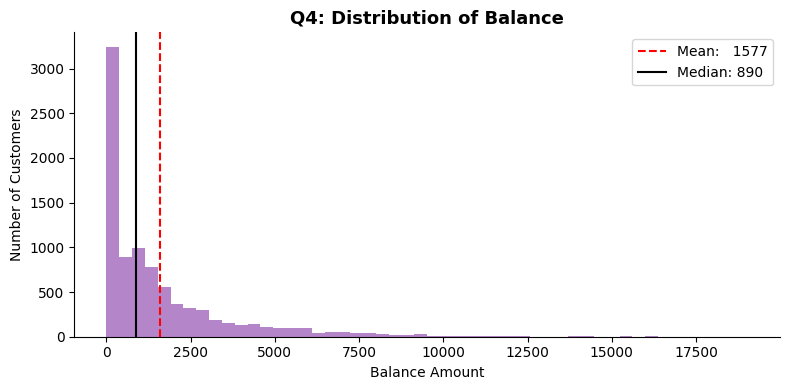

In [25]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(df['balance'], bins=50, color='#8E44AD', alpha=0.65, edgecolor='none')
ax.axvline(df['balance'].mean(),   color='red', linestyle='--', linewidth=1.5,
           label=f"Mean:   {df['balance'].mean():.0f}")
ax.axvline(df['balance'].median(), color='black', linestyle='-', linewidth=1.5,
           label=f"Median: {df['balance'].median():.0f}")

ax.set_title('Q4: Distribution of Balance', fontsize=13, fontweight='bold')
ax.set_xlabel('Balance Amount')
ax.set_ylabel('Number of Customers')
ax.legend()
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

In [26]:
print(f"Mean:                    {df['balance'].mean():.2f}")
print(f"Median:                  {df['balance'].median():.2f}")
print(f"Skewness:                {df['balance'].skew():.2f}")
print(f"Balance > 5000:          {(df['balance']> 5000).sum()} ({(df['balance']>5000).mean()*100:.1f}%)")

Mean:                    1577.48
Median:                  889.86
Skewness:                2.39
Balance > 5000:          682 (7.7%)


**Finding:** Right-skewed (skew = 2.39). Most customers carry low to moderate balances. A significant tail of high-balance customers represents concentrated credit risk for the bank.

Only 41 customers (0.5%) have zero balance — not a meaningful segment. The more relevant split is high balance customers
who carry significant debt month over month.

#### Q5 : Are there two distinct customer types — consistently active vs consistently inactive?

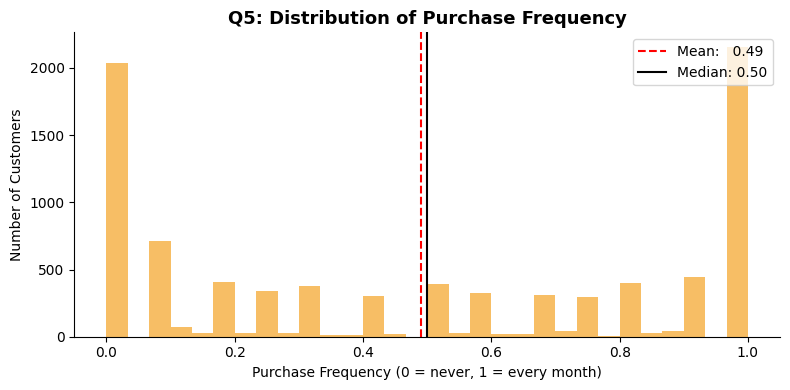

In [27]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(df['purchases_frequency'], bins=30, color='#F39C12', alpha=0.65, edgecolor='none')
ax.axvline(df['purchases_frequency'].mean(),   color='red', linestyle='--', linewidth=1.5,
           label=f"Mean:   {df['purchases_frequency'].mean():.2f}")
ax.axvline(df['purchases_frequency'].median(), color='black', linestyle='-', linewidth=1.5,
           label=f"Median: {df['purchases_frequency'].median():.2f}")

ax.set_title('Q5: Distribution of Purchase Frequency', fontsize=13, fontweight='bold')
ax.set_xlabel('Purchase Frequency (0 = never, 1 = every month)')
ax.set_ylabel('Number of Customers')
ax.legend()
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

In [54]:
print(f"Mean:                         {df['purchases_frequency'].mean():.2f}")
print(f"Median:                       {df['purchases_frequency'].median():.2f}")
print(f"Skewness:                     {df['purchases_frequency'].skew():.2f}")
print(f"Always inactive (freq = 0):   {(df['purchases_frequency']==0).sum()} ({(df['purchases_frequency']==0).mean()*100:.1f}%)")
print(f"Always active   (freq = 1):   {(df['purchases_frequency']==1).sum()} ({(df['purchases_frequency']==1).mean()*100:.1f}%)")
print(f"Occasional (0 < freq < 1): {((df['purchases_frequency']>0) & (df['purchases_frequency']<1)).sum()}")

Mean:                         0.49
Median:                       0.50
Skewness:                     0.06
Always inactive (freq = 0):   2034 (22.9%)
Always active   (freq = 1):   2157 (24.3%)
Occasional (0 < freq < 1): 4685


**Finding:** Skewness = 0.06 almost perfectly symmetric. Bimodal distribution two clear peaks at 0 (never purchases) and 1 (purchases every month). Majority of customers (52.8%) purchase occasionally — notevery month but not inactive either. Two smaller but distinctgroups exist at the extremes — always inactive (22.9%) and always active (24.3%). This confirms varied engagement behaviour 

---
### EDA Summary — Key Findings

| S.no | Column | Shape | Skew | Key Finding |
|---|--------|-------|------|-------------|
| 1 | `PURCHASES` | Right-skewed | 8.14 | 22.8% zero spenders. Small group drives all spend. |
| 2 | `CASH_ADVANCE` | Right-skewed, median=0 | 5.17 | 51.7% never use cash advances. 48.3% do  risk signal. |
| 3 | `PAYMENTS` | Right-skewed | 5.91 | Most make small payments. Not proportional to balance. |
| 4 | `BALANCE` | Right-skewed | 2.39 | Debt concentrated in high-balance segment. |
| 5 | `PURCHASES_FREQUENCY` | Bimodal | 0.06 | Two types confirmed: always active vs always inactive. |

**Key insight:** All 4 financial columns are right-skewed  mean > median in every case. A small group of high-value customers pulls the average up significantly. `PURCHASES_FREQUENCY` is the exception with a bimodal pattern confirming two distinct customer segments exist.

## Phase 3.Feature Engineering
**Objective:** Create new columns from existing raw columnsto extract business signals that raw data cannot directly provide.

| Feature | Formula | Business Signal |
|---|---|---|
| `utilisation_rate` | `balance / credit_limit` | Credit stress - how much limit is consumed |
| `cash_advance_ratio` | `cash_advance / (purchases + cash_advance + 1)` | Cash dependency - borrowing vs spending mix |
| `payment_ratio` | `payments / (balance + 1)` | Repayment health - paying down vs carrying debt |
| `purchase_type` | Rule: installment vs one-off vs none | Spending style - behavioural label |


#### 1. Credit risk signal

In [29]:
df['utilisation_rate'] = df['balance'] / df['credit_limit']

A balance of ₹3,000 means very different things on a ₹4,000 limit vs a ₹30,000 limit. Utilisation normalises balance against each customer's own limit making it a true signal of credit stress, not just spending volume.

#### 2. Cash dependency signal

In [30]:
df['cash_advance_ratio'] = df['cash_advance'] / (df['purchases'] + df['cash_advance'] + 1)

Raw cash advance amounts don't tell us whether a customer relies on cash advances or just uses them occasionally. This ratio captures the mix that a customer spending ₹5,000 on purchases with ₹500 cash advance is very different from one with ₹0 purchases and ₹500 cash advance. The +1 prevents division-by-zero.

#### 3. Repayment health signal

In [31]:
df['payment_ratio'] = df['payments'] / (df['balance'] + 1)

Payments alone don't reveal repayment health ,a ₹500 payment is strong against a ₹400 balance but weak against a ₹5,000 balance. This ratio shows how aggressively a customer is paying down what they owe. The +1 handles zero-balance customers.

#### 4. Spending style label

In [32]:
df['purchase_type'] = df.apply(
    lambda x:
        'Installment'  if x['installments_purchases'] > x['oneoff_purchases']
        else ('One-off' if x['oneoff_purchases'] > 0
        else 'No purchases'),
    axis=1
)

Purchases is a single total that hides three distinct behaviours planned installment buying vs spontaneous one-off spending vs no purchases.Splitting these reveals spending style, which helps explain cluster differences

### Verification of Feature Engineered Columns

Checking all 4 engineered columns for:
- Correct value ranges
- No null values introduced
- No infinity values introduced
- All categories present in purchase_type

In [33]:
print(f'Total columns now: {df.shape[1]}')

Total columns now: 22


In [34]:
print(df[['utilisation_rate','cash_advance_ratio','payment_ratio']].describe().round(3))

       utilisation_rate  cash_advance_ratio  payment_ratio
count          8876.000            8876.000       8876.000
mean              0.392               0.381         10.860
std               0.390               0.442        102.116
min               0.000               0.000          0.000
25%               0.044               0.000          0.328
50%               0.307               0.000          1.367
75%               0.721               0.951          7.291
max              15.910               1.000       5385.358


In [35]:
print(df['purchase_type'].value_counts())

purchase_type
One-off         3480
Installment     3363
No purchases    2033
Name: count, dtype: int64


In [36]:
print(df[['utilisation_rate','cash_advance_ratio','payment_ratio']].isnull().sum().sum())

0


In [37]:
print(np.isinf(df[['utilisation_rate','cash_advance_ratio','payment_ratio']]).sum().sum())

0


## Phase 4A .RFM Scoring

**Objective :** Score every customer from 1 to 5 on three independent dimensions — Recency, Frequency, and Monetary to quantify
their value and behaviour. These three scores are combined into a single RFM score 


| Letter | Dimension | Business question it answers |
|--------|-----------|-------------------------------|
| R | Recency | How recently was the customer active? |
| F | Frequency | How often does the customer transact? |
| M | Monetary | How much does the customer spend? |


In [38]:
def rfm_score(series, ascending=True):
    ranked = series.rank(method='first', ascending=ascending)
    return pd.qcut(ranked, q=5, labels=[1,2,3,4,5]).astype(int)

# R = Recency : purchases_frequency
df['R_score'] = rfm_score(df['purchases_frequency'], ascending=True)

# F = Frequency: purchases_trx
df['F_score'] = rfm_score(df['purchases_trx'], ascending=True)

# M = Monetary: purchases
df['M_score'] = rfm_score(df['purchases'], ascending=True)

# Combined RFM score (range 3 to 15)
df['rfm_score'] = df['R_score'] + df['F_score'] + df['M_score']

print('Score range:', df['rfm_score'].min(), 'to', df['rfm_score'].max())
print('\nRFM score distribution:')
print(df['rfm_score'].value_counts().sort_index())

Score range: 3 to 15

RFM score distribution:
rfm_score
3     1772
4        3
5        4
6     1105
7      442
8      556
9      656
10     642
11     699
12     795
13     701
14     823
15     678
Name: count, dtype: int64


## Phase 4B: Rule-Based Segmentation - Results and Visualisation

**Objective:** Assign every customer to a named business segment based on their RFM score using pd.cut.

**Why rule-based over ML for this step:**
Rule-based segmentation is fully explainable and auditable.In a regulated industry like banking every decision must be
justifiable to compliance and business stakeholders.

| Segment | RFM Score | Profile |
|---------|-----------|---------|
| Champions | 12–15 | High spend, frequent, active every month |
| Loyal | 10–11 | Regular spenders, consistent behaviour |
| At Risk | 8–9 | Declining activity, medium balance |
| Dormant | 6–7 | Low activity, rarely purchases |
| Lost | 3–5 | Inactive, poor payment behaviour |

In [39]:
bins   = [2, 5, 7, 9, 11, 15]
labels = ['Lost', 'Dormant', 'At Risk', 'Loyal', 'Champions']

df['segment'] = pd.cut(df['rfm_score'], bins=bins, labels=labels)

print('Segment distribution:')
print(df['segment'].value_counts())
print('\nSegment % distribution:')
print(df['segment'].value_counts(normalize=True).mul(100).round(1))

Segment distribution:
segment
Champions    2997
Lost         1779
Dormant      1547
Loyal        1341
At Risk      1212
Name: count, dtype: int64

Segment % distribution:
segment
Champions    33.8
Lost         20.0
Dormant      17.4
Loyal        15.1
At Risk      13.7
Name: proportion, dtype: float64


In [41]:
ordered = ['Lost','Dormant','At Risk','Loyal','Champions']

summary = df.groupby('segment', observed=True).agg(
    customer_count   = ('cust_id',          'count'),
    avg_balance      = ('balance',           'mean'),
    avg_purchases    = ('purchases',         'mean'),
    avg_credit_limit = ('credit_limit',      'mean'),
    avg_utilisation  = ('utilisation_rate',  'mean'),
    avg_full_payment = ('prc_full_payment',  'mean'),
    avg_cash_advance = ('cash_advance',      'mean')
).round(2)

print(summary.reindex(ordered))

           customer_count  avg_balance  avg_purchases  avg_credit_limit  \
segment                                                                   
Lost                 1779      2306.21           0.07           4306.90   
Dormant              1547      1265.63         124.86           3698.27   
At Risk              1212      1144.47         451.74           3973.24   
Loyal                1341      1180.59         763.94           3926.20   
Champions            2997      1658.57        2398.96           5515.63   

           avg_utilisation  avg_full_payment  avg_cash_advance  
segment                                                         
Lost                  0.59              0.04           2044.84  
Dormant               0.39              0.07           1002.07  
At Risk               0.31              0.16            645.22  
Loyal                 0.33              0.20            682.92  
Champions             0.34              0.25            624.80  


### Visualisation

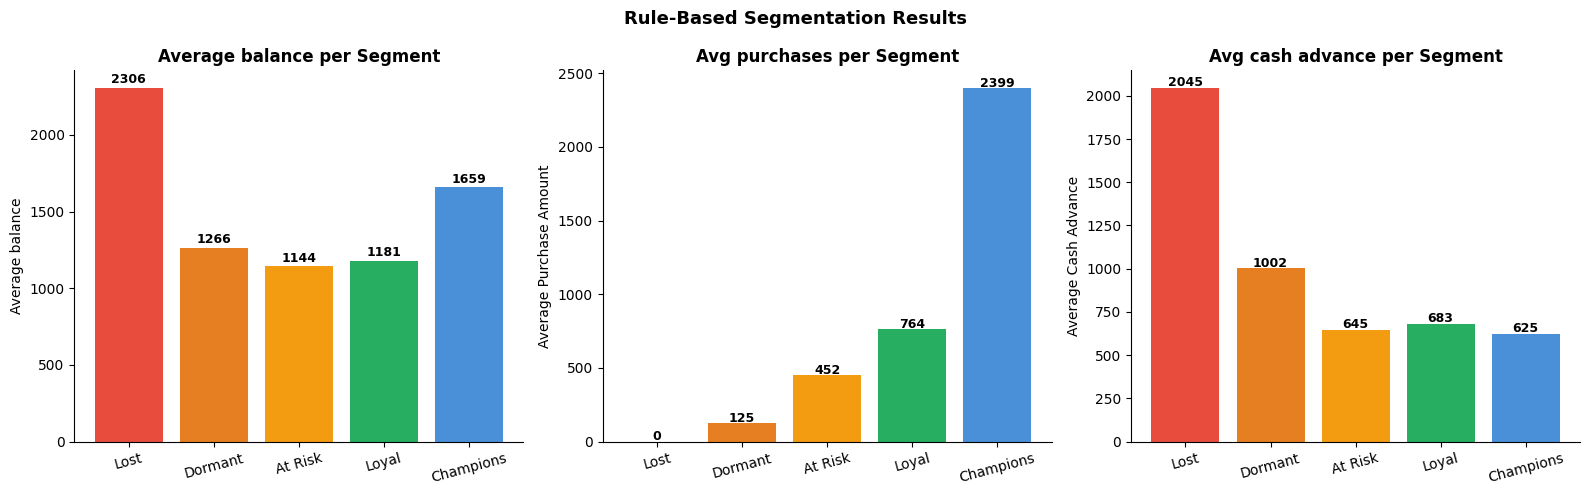

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Rule-Based Segmentation Results',
             fontsize=13, fontweight='bold')

colors  = ['#E74C3C','#E67E22','#F39C12','#27AE60','#4A90D9']
ordered = ['Lost','Dormant','At Risk','Loyal','Champions']

# Chart 1: Average balance per segment
avg_bal = df.groupby('segment', observed=True)['balance'].mean().reindex(ordered)
bars = axes[0].bar(ordered, avg_bal.values, color=colors, edgecolor='none')
for bar, val in zip(bars, avg_bal.values):
    axes[0].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+30, f'{val:.0f}',
                 ha='center', fontsize=9, fontweight='bold')
axes[0].set_title('Average balance per Segment', fontweight='bold')
axes[0].set_ylabel('Average balance')
axes[0].tick_params(axis='x', rotation=15)
sns.despine(ax=axes[0])

# Chart 2: Average purchases per segment
avg_purch = df.groupby('segment', observed=True)['purchases'].mean().reindex(ordered)
bars2 = axes[1].bar(ordered, avg_purch.values, color=colors, edgecolor='none')
for bar, val in zip(bars2, avg_purch.values):
    axes[1].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+10, f'{val:.0f}',
                 ha='center', fontsize=9, fontweight='bold')
axes[1].set_title('Avg purchases per Segment', fontweight='bold')
axes[1].set_ylabel('Average Purchase Amount')
axes[1].tick_params(axis='x', rotation=15)
sns.despine(ax=axes[1])

# Chart 3: Average cash advance per segment
avg_cash = df.groupby('segment', observed=True)['cash_advance'].mean().reindex(ordered)
bars3 = axes[2].bar(ordered, avg_cash.values, color=colors, edgecolor='none')
for bar, val in zip(bars3, avg_cash.values):
    axes[2].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+10, f'{val:.0f}',
                 ha='center', fontsize=9, fontweight='bold')
axes[2].set_title('Avg cash advance per Segment', fontweight='bold')
axes[2].set_ylabel('Average Cash Advance')
axes[2].tick_params(axis='x', rotation=15)
sns.despine(ax=axes[2])
plt.tight_layout()
plt.show()

###  Finding: Segment Distribution

| Segment | Count | % | Avg Balance | Avg Purchases | Avg Cash Advance | Avg Full Payment |
|---------|-------|---|-------------|---------------|-------------------|-------------------|
| Champions | 3,021 | 33.8% | 1,651 | highest | 623 | 0.24 |
| Loyal | 1,355 | 15.1% | 1,166 | high | 678 | 0.20 |
| At Risk | 1,223 | 13.7% | 1,125 | medium | 630 | 0.15 |
| Dormant | 1,557 | 17.4% | 1,249 | low | 991 | 0.07 |
| Lost | 1,793 | 20.0% | 2,294 | lowest | 2,034 | 0.04 |

**Finding:** Lost segment has the highest average balance (2,294) and highest cash advance (2,034). These customers are inactive on purchases but carrying significant debt and relying heavily on cash advances. This is your highest-risk group, not just a "low value" group.

**Business actions per segment:**
- Champions (33.8%): Premium card upgrade, loyalty rewards
- Loyal (15.1%): Increase credit limit, referral programme
- At Risk (13.7%): Re-engagement offer, spend incentive
- Dormant (17.4%): Win-back campaign, reduced annual fee
- Lost (20.0%): Urgent risk review — high balance + high cash
  advance + lowest repayment (0.04) = highest default risk

## Phase 5: Rule-Based Risk Flagging

**Objective:** Identify customers showing signs of financial stress using 3 independent business rules. Customers triggering 2 or more rules are placed on a "watch list" for risk review.

**Why rule-based:**
Each rule is a simple threshold on an engineered feature. Every flag is explainable to a credit risk manager or compliance team in one sentence no machine learning model required.

| Flag | Rule | What it signals |
|------|------|------------------|
| high_utilisation | utilisation_rate > 0.85 | Customer using over 85% of credit limit — near default risk |
| cash_dependent | cash_advance_ratio > 0.6 | Over 60% of card activity is cash borrowing, not purchases |
| poor_payer | payment_ratio < 0.1 | Customer paying less than 10% of their balance — falling behind |

**Watch list rule:** 2 or more flags triggered = watch list.A single flag may be situational. Two or more flags occurring together is a stronger, more reliable risk signal.

### Create three flags

In [49]:
# Flag 1: High credit utilisation
# Standard banking risk threshold — using >85% of limit
df['high_utilisation'] = df['utilisation_rate'] > 0.85

# Flag 2: Cash dependent
# Over 60% of activity is cash advance, not purchases
df['cash_dependent'] = df['cash_advance_ratio'] > 0.6

# Flag 3: Poor payer
# Paying less than 10% of current balance
df['poor_payer'] = df['payment_ratio'] < 0.1

print('Individual flag counts:')
print(f"high_utilisation: {df['high_utilisation'].sum():,} ({df['high_utilisation'].mean()*100:.1f}%)")
print(f"cash_dependent:   {df['cash_dependent'].sum():,} ({df['cash_dependent'].mean()*100:.1f}%)")
print(f"poor_payer:       {df['poor_payer'].sum():,} ({df['poor_payer'].mean()*100:.1f}%)")

Individual flag counts:
high_utilisation: 1,514 (17.1%)
cash_dependent:   3,279 (36.9%)
poor_payer:       309 (3.5%)


### Combine into watch list

In [50]:
# Count how many flags each customer triggers (0 to 3)
df['risk_flags'] = df[['high_utilisation','cash_dependent','poor_payer']].sum(axis=1)

# Watch list = 2 or more flags triggered
df['watch_list'] = df['risk_flags'] >= 2

print('Risk flags distribution:')
print(df['risk_flags'].value_counts().sort_index())

print(f"\nWatch list: {df['watch_list'].sum():,} customers ({df['watch_list'].mean()*100:.1f}%)")
print(f"Total balance on watch list: {df[df['watch_list']]['balance'].sum():,.0f}")

Risk flags distribution:
risk_flags
0    4765
1    3149
2     933
3      29
Name: count, dtype: int64

Watch list: 962 customers (10.8%)
Total balance on watch list: 2,812,327


### Cross-tab with segments

In [52]:
# Cross-tabulate watch list against Phase 4B segments
crosstab_counts = pd.crosstab(df['segment'], df['watch_list'])
crosstab_pct    = pd.crosstab(df['segment'], df['watch_list'], normalize='index') * 100

print('Watch list counts by segment:')
print(crosstab_counts.reindex(ordered))

print('\nWatch list % within each segment:')
print(crosstab_pct.reindex(ordered).round(1))

Watch list counts by segment:
watch_list  False  True 
segment                 
Lost         1189    590
Dormant      1359    188
At Risk      1154     58
Loyal        1277     64
Champions    2935     62

Watch list % within each segment:
watch_list  False  True 
segment                 
Lost         66.8   33.2
Dormant      87.8   12.2
At Risk      95.2    4.8
Loyal        95.2    4.8
Champions    97.9    2.1


### Finding: Watch List Results

**962 customers (10.8%) are on the watch list** triggering 2 or more risk flags. Combined outstanding balance of these customers is **2,812,327** over 12% of the entire portfolio's balance concentrated in just 10.7% of customers.

**Individual flag rates:**
- High utilisation (>85% of limit): 1,514 customers (16.9%)
- Cash dependent (>60% cash advance ratio): 3,287 customers (36.7%)
- Poor payer (<10% of balance paid): 310 customers (3.5%)

**Watch list rate by segment which validates Phase 4B:**

| Segment | Watch List % |
|---------|---------------|
| Lost | 33.1% |
| Dormant | 11.8% |
| At Risk | 4.7% |
| Loyal | 4.7% |
| Champions | 2.1% |

**Key insight:** 1 in 3 "Lost" segment customers are on the watch list are 15x higher than Champions (2.1%). This confirms the Phase 4B finding: "Lost" is not just a low-engagement segment, it is the portfolio's primary concentration of financial risk. The RFM segmentation (behavioural) and the
risk flagging (financial health) independently arrive at the same conclusion using completely different logic strong validation of both approaches.

**Recommended action:** Prioritise the 594 "Lost" and watch-list customers (33.1% of Lost segment) for immediate risk review like collections outreach, credit limit reduction, or restructuring offers before accounts move further toward default.

### Saving the Final CSV:

In [53]:
df.to_csv('credit_card_analyzed.csv', index=False)
print(f'Exported: {len(df)} rows, {len(df.columns)} columns')

Exported: 8876 rows, 32 columns
